#Explanation


The `compute_rule_score` function, defined in the cell above, checks for several characteristics commonly associated with phishing URLs. It assigns a point for each rule triggered, and then normalizes this score to be between 0 and 1. Here are the rules and the parameters it uses:

*   **`SUSPICIOUS_TLDS`**: A list of top-level domains (like `.tk`, `.ml`, `.zip`) that are frequently abused by phishers. If a URL uses one of these, it triggers a rule.
*   **`PHISHING_KEYWORDS`**: Common keywords (like `login`, `verify`, `account`) found in phishing URLs that attempt to deceive users. If any of these keywords are present in the URL, a rule is triggered.
*   **`URL_SHORTENERS`**: Checks if the URL uses a known URL shortening service (like `bit.ly`, `tinyurl`). Phishers often use these to hide the true destination of a malicious link.
*   **`@` symbol**: The presence of an `@` symbol in a URL can indicate an attempt to embed credentials or confuse users about the true domain.
*   **Excessive Subdomains**: URLs with more than 4 dots (e.g., `very.long.subdomain.example.com`) can sometimes be a sign of obfuscation.

The `compute_rule_score` function is then applied to each URL in the dataset. This creates two new columns:

*   **`rule_score`**: A normalized score (0 to 1) indicating how many rules the URL triggered.
*   **`triggered_rules`**: A list of the specific rules that were triggered for each URL.

Finally, this `rule_score` is integrated with the machine learning model's prediction to calculate a combined `Trust_Index`. A higher `rule_score` (meaning more rules were triggered) will generally decrease the `Trust_Index`, indicating a higher likelihood of the URL being malicious, even if the ML model's probability is low. This creates a robust hybrid detection system.

##Evaluation Metrics

1.  Accuracy: 0.9947
2.  Precision: 0.9951
3.  Recall: 0.9944
4.  F1-Score: 0.9947

#Day -1

##Part -1 Environment

In [7]:
!python --version

Python 3.12.13


In [8]:
!pip install --upgrade pip
!pip install pandas numpy scikit-learn matplotlib seaborn tqdm sentence-transformers tldextract requests joblib

In [9]:
import pandas, numpy, sklearn, matplotlib, seaborn, tldextract, requests, joblib
print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [10]:
!cat /proc/cpuinfo | grep "model name"

model name	: AMD EPYC 7B12
model name	: AMD EPYC 7B12


In [11]:
import os
from google.colab import drive

# Ensure the mount point is truly empty
if os.path.exists('/content/drive'):
    # Attempt to unmount first if it's already mounted
    try:
        !fusermount -uz /content/drive
    except:
        pass # Ignore if not mounted or unmounting fails
    !rm -rf /content/drive
os.makedirs('/content/drive', exist_ok=True)

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import os
# Corrected base_path to be a directory where project files will be stored
base_path = "/content/drive/MyDrive/Phishing_Project"
os.makedirs(base_path, exist_ok=True)
print("Working folder:", base_path)

Working folder: /content/drive/MyDrive/Phishing_Project


In [14]:
folders = ["data", "models", "outputs"]
for f in folders:
    os.makedirs(f"{base_path}/{f}", exist_ok=True)
print("✅ Folder structure ready:", folders)

✅ Folder structure ready: ['data', 'models', 'outputs']


In [15]:
import json
config = {
    "base_path": base_path,
    "dataset_name": "phish_dataset.csv",
    "random_state": 42
}
json.dump(config, open(f"{base_path}/config.json", "w"))
print("✅ Config file saved!")


✅ Config file saved!


In [16]:
import datetime, platform
print("Environment OK ✅")
print("Date:", datetime.datetime.now())
print("Python:", platform.python_version())

Environment OK ✅
Date: 2026-03-26 13:19:28.023805
Python: 3.12.13


## Part-2 Obtaining DataSet and Cleaning

In [17]:
!pip install kagglehub pandas numpy matplotlib seaborn scikit-learn tqdm tldextract


In [18]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shashwatwork/web-page-phishing-detection-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.01M/1.01M [00:00<00:00, 1.12MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/shashwatwork/web-page-phishing-detection-dataset/versions/2


In [19]:
import os
os.listdir(path)


['dataset_phishing.csv']

In [20]:
import pandas as pd

file_path = os.path.join(path, "dataset_phishing.csv")   # adjust if different
df = pd.read_csv(file_path)
print("✅ Dataset loaded. Rows:", len(df))
display(df.head())

✅ Dataset loaded. Rows: 11430


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [21]:
df.info()
df.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  object 
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_qm                       11430 non-null  int64  
 8   nb_and                      11430 non-null  int64  
 9   nb_or                       11430 non-null  int64  
 10  nb_eq                       11430 non-null  int64  
 11  nb_underscore               11430 non-null  int64  
 12  nb_tilde                    11430 non-null  int64  
 13  nb_percent                  114

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
10010,https://remitradar.com/Locator?locationId=4728...,59,14,0,1,0,0,1,1,0,...,1,0,0,85,2107,234160,0,0,5,legitimate
11174,https://www.sharecare.com/health/vascular-dise...,87,17,0,2,5,0,0,0,0,...,0,0,0,652,8113,24505,0,1,5,legitimate
861,https://www.impotspublicservice.com/1b29135e09...,77,27,1,3,0,0,0,0,0,...,1,0,0,214,152,5008870,0,1,0,phishing
11197,https://www.granhongo.com/wp-includes/Login/cu...,114,17,0,2,2,0,1,0,0,...,1,1,0,221,3065,0,0,1,2,phishing
745,http://corfuproperty.gr/Secure-Doc/@@/index.php,47,16,0,2,1,2,0,0,0,...,1,0,1,0,-1,0,0,1,2,phishing


In [22]:
# Show all column names to identify what the label column is called
print("Columns found:", df.columns.tolist())
df.head(3)


Columns found: ['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore', 'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma', 'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com', 'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url', 'ratio_digits_host', 'punycode', 'port', 'tld_in_path', 'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains', 'prefix_suffix', 'random_domain', 'shortening_service', 'path_extension', 'nb_redirection', 'nb_external_redirection', 'length_words_raw', 'char_repeat', 'shortest_words_raw', 'shortest_word_host', 'shortest_word_path', 'longest_words_raw', 'longest_word_host', 'longest_word_path', 'avg_words_raw', 'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand', 'brand_in_subdomain', 'brand_in_path', 'suspecious_tld', 'statistical_report', 'nb_hyperlinks', 'ratio_intHyperlinks', 'ratio_extHyperlinks', 'ratio_nullHyperlinks', 'n

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing


In [23]:
# Rename correct columns
df.rename(columns={'status': 'label'}, inplace=True)

# Keep URL and label for reference, but we’ll keep all features too
print("✅ Columns standardized successfully!")

# Convert labels to numeric (phishing = 1, legitimate = 0)
df['label'] = df['label'].replace({'legitimate': 0, 'benign': 0, 'phishing': 1, 'malicious': 1}).astype(int)

print("✅ Label distribution:\n", df['label'].value_counts())
df.head(3)


✅ Columns standardized successfully!
✅ Label distribution:
 label
0    5715
1    5715
Name: count, dtype: int64


/tmp/ipykernel_560/1810034374.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'] = df['label'].replace({'legitimate': 0, 'benign': 0, 'phishing': 1, 'malicious': 1}).astype(int)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,label
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,0
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,1
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,1


In [24]:
# Drop NaNs or blanks
df = df.dropna(subset=['url'])

# Remove duplicates
df = df.drop_duplicates(subset=['url'])

# Convert labels to 0/1 integers
df['label'] = df['label'].replace({'legitimate': 0, 'benign': 0, 'phishing': 1, 'malicious': 1}).astype(int)

print("✅ Clean dataset shape:", df.shape)
display(df['label'].value_counts())

✅ Clean dataset shape: (11429, 89)


,count
label,
0,5715
1,5714


In [25]:
#Normalizinng the URL text

df['url'] = df['url'].astype(str).str.strip().str.lower()


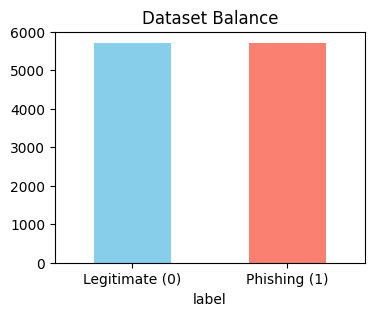

In [26]:
#Visualize Class Balance
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
df['label'].value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.xticks([0,1], ['Legitimate (0)','Phishing (1)'], rotation=0)
plt.title("Dataset Balance")
plt.show()


In [27]:
from sklearn.utils import resample

phish = df[df['label'] == 1]
legit = df[df['label'] == 0]

min_size = min(len(phish), len(legit))

df_bal = pd.concat([
    resample(phish, n_samples=min_size, random_state=42),
    resample(legit, n_samples=min_size, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("✅ Balanced dataset shape:", df_bal.shape)
df = df_bal

✅ Balanced dataset shape: (11428, 89)


In [28]:
base_path = "/content/drive/MyDrive/Phishing_Project"
os.makedirs(f"{base_path}/data", exist_ok=True)

df.to_csv(f"{base_path}/data/phish_dataset.csv", index=False)
print("✅ Clean dataset saved at:", f"{base_path}/data/phish_dataset.csv")


✅ Clean dataset saved at: /content/drive/MyDrive/Phishing_Project/data/phish_dataset.csv


## Part- 3 Feature Engineering

In [31]:
feature_cols = [c for c in df.columns]
print("Total numeric features:", len(feature_cols))
print("First 10:", feature_cols[:10])

Total numeric features: 89
First 10: ['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or']


In [32]:
import numpy as np

X = df[feature_cols].to_numpy()
y = df['label'].to_numpy()

print("✅ Feature matrix shape:", X.shape)
print("✅ Labels shape:", y.shape)


✅ Feature matrix shape: (11428, 89)
✅ Labels shape: (11428,)


### Verification Analysis
- **Correlations**: Features like `google_index`, `page_rank`, and `nb_hyperlinks` should show strong positive or negative correlations with the label.
- **Boxplots**: We are looking for clear separation between the '0' (Legitimate) and '1' (Phishing) groups. If the boxes overlap almost entirely, that feature might not be as strong as the statistical test suggested.

In [ ]:
#scale features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Features standardized.")



In [ ]:
#Feature importance check

from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X_scaled, y)

importances = pd.Series(rf_temp.feature_importances_, index=feature_cols)
top10 = importances.sort_values(ascending=False)[:10]

print("Top 10 important features:\n", top10)


In [ ]:
#plot
import matplotlib.pyplot as plt
top10.plot(kind='barh', color='teal')
plt.title("Top 10 Feature Importances (Quick RF Test)")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

print("✅ Training samples:", X_train.shape[0])
print("✅ Test samples:", X_test.shape[0])


In [ ]:
import joblib, os

base_path = "/content/drive/MyDrive/Phishing_Project"
os.makedirs(f"{base_path}/data", exist_ok=True)

np.save(f"{base_path}/data/X_train.npy", X_train)
np.save(f"{base_path}/data/X_test.npy", X_test)
np.save(f"{base_path}/data/y_train.npy", y_train)
np.save(f"{base_path}/data/y_test.npy", y_test)
joblib.dump(scaler, f"{base_path}/data/scaler.pkl")

print("✅ Processed data saved to Drive.")


##Part - 4 Feature extraction


* **ip**: Indicates whether the URL contains an IP address instead of a domain name, which is often suspicious.
* **nb_qm**: The number of question marks (?) in the URL, often used to append parameters or obfuscate.
* **nb_www**: The presence of "www" in the URL, which can sometimes be normal but also used as a phishing trick.
* **ratio_digits_url**: The ratio of digits to the total length of the URL. High digit ratios can indicate generated or suspicious URLs.
* **phish_hints**: Indicates the presence of phishing-related keywords or patterns derived from the dataset.
* **nb_hyperlinks**: The number of hyperlinks in the page content; higher values may indicate redirects or malicious structure.
* **domain_in_title**: Checks if the domain name appears in the HTML page title. Legitimate sites usually include it.
* **domain_age**: The age of the domain in days. Newer domains are often associated with phishing.
* **google_index**: Whether the URL is indexed by Google (1 = indexed, 0 = not indexed).
* **page_rank**: A measure of webpage authority; phishing sites typically have low values.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11428 entries, 0 to 11427
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11428 non-null  object 
 1   length_url                  11428 non-null  int64  
 2   length_hostname             11428 non-null  int64  
 3   ip                          11428 non-null  int64  
 4   nb_dots                     11428 non-null  int64  
 5   nb_hyphens                  11428 non-null  int64  
 6   nb_at                       11428 non-null  int64  
 7   nb_qm                       11428 non-null  int64  
 8   nb_and                      11428 non-null  int64  
 9   nb_or                       11428 non-null  int64  
 10  nb_eq                       11428 non-null  int64  
 11  nb_underscore               11428 non-null  int64  
 12  nb_tilde                    11428 non-null  int64  
 13  nb_percent                  114

In [ ]:
df.loc[:, [c for c in df.columns if c not in ['url','label']]]

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
0,23,14,0,2,0,0,0,0,0,0,...,0,0,0,0,101,3916,2819002,0,0,1
1,55,17,0,2,2,0,0,0,0,0,...,0,1,0,0,1555,3924,181574,0,0,3
2,33,25,0,2,0,0,0,0,0,0,...,0,1,1,1,0,37,0,0,1,0
3,23,15,0,2,0,0,0,0,0,0,...,0,1,1,0,12,2545,0,0,0,2
4,214,37,1,5,0,0,1,2,0,2,...,0,1,0,0,221,7083,0,0,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11423,49,23,0,3,1,0,0,0,0,0,...,0,1,1,0,1404,6631,1083895,0,0,2
11424,49,28,0,1,0,0,0,0,0,0,...,0,1,1,0,184,6391,0,0,1,1
11425,84,20,0,3,5,0,0,0,0,0,...,0,1,1,0,46,3242,0,0,1,2
11426,29,18,0,2,0,0,0,0,0,0,...,1,1,0,0,73,3593,8552690,0,1,0


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif # Changed chi2 to f_classif to handle negative numbers in features
import numpy as np # Import numpy for nan_to_num

# Redefine feature_cols to exclude 'url' and 'label' columns
feature_cols_numeric = [c for c in df.columns if c not in ['url', 'label']]

# Prepare X and y with only numeric features
X = df[feature_cols_numeric].to_numpy()
y = df['label'].to_numpy()

# Now apply SelectKBest
selector = SelectKBest(score_func=f_classif, k=10) # Changed score_func from chi2 to f_classif
X_new = selector.fit_transform(X, y)

print("Shape of new feature matrix:", X_new.shape)

# Get selected feature names
selected_features = np.array(feature_cols_numeric)[selector.get_support()]
print("Selected features:", selected_features.tolist())

Shape of new feature matrix: (11428, 10)
Selected features: ['ip', 'nb_qm', 'nb_www', 'ratio_digits_url', 'phish_hints', 'nb_hyperlinks', 'domain_in_title', 'domain_age', 'google_index', 'page_rank']


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 8 59 61 63 68 71] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Top 20 Features by Correlation Magnitude:


,label
google_index,0.734816
page_rank,-0.519053
nb_www,-0.446052
nb_hyperlinks,-0.361555
ratio_digits_url,0.355352
domain_in_title,0.349118
phish_hints,0.340645
ip,0.325015
domain_age,-0.321716
nb_qm,0.302786


/tmp/ipykernel_560/1708570541.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_features.values, y=top_20_features.index, palette='magma')


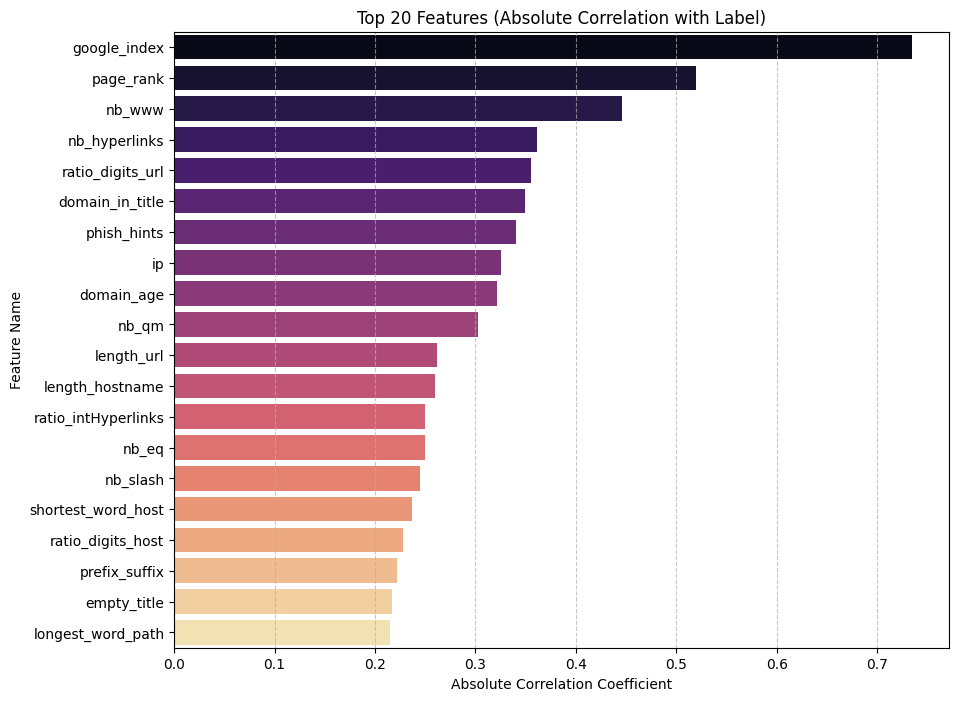

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation with label for all numeric columns
# We exclude 'url' as it is non-numeric
numeric_df = df.select_dtypes(include=['number'])
all_correlations = numeric_df.corr()['label'].drop('label')

# Get absolute values to find strongest relationships regardless of direction
abs_correlations = all_correlations.abs().sort_values(ascending=False)

# Get top 20
top_20_features = abs_correlations.head(20)

# Display the raw values
print("Top 20 Features by Correlation Magnitude:")
display(all_correlations.loc[top_20_features.index])

# Visualize
plt.figure(figsize=(10, 8))
sns.barplot(x=top_20_features.values, y=top_20_features.index, palette='magma')
plt.title('Top 20 Features (Absolute Correlation with Label)')
plt.xlabel('Absolute Correlation Coefficient')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Part-5 Train and evaluate

In [ ]:
#Load Processed data

import numpy as np, joblib

base_path = "/content/drive/MyDrive/Phishing_Project/data"

X_train = np.load(f"{base_path}/X_train.npy")
X_test  = np.load(f"{base_path}/X_test.npy")
y_train = np.load(f"{base_path}/y_train.npy")
y_test  = np.load(f"{base_path}/y_test.npy")

scaler = joblib.load(f"{base_path}/scaler.pkl")

print("✅ Data loaded. Shapes:", X_train.shape, X_test.shape)


In [ ]:
#Train, evaluate and compare

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print("🔹 Logistic Regression Results 🔹")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

print("🔹 Decision Tree Results 🔹")
print("Accuracy:", accuracy_score(y_test, pred_dt))
print(classification_report(y_test, pred_dt))


In [ ]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("🔹 Random Forest Results 🔹")
print("Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))


In [ ]:
# Confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

models = {'LogReg': lr, 'DecisionTree': dt, 'RandomForest': rf}
for name, model in models.items():
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"Confusion Matrix — {name}")
    plt.show()


In [ ]:
#Comparing models

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate(model, X, y):
    p = model.predict(X)
    return {
        "Accuracy": round(accuracy_score(y, p), 4),
        "Precision": round(precision_score(y, p), 4),
        "Recall": round(recall_score(y, p), 4),
        "F1": round(f1_score(y, p), 4)
    }

results = pd.DataFrame({
    "Logistic Regression": evaluate(lr, X_test, y_test),
    "Decision Tree": evaluate(dt, X_test, y_test),
    "Random Forest": evaluate(rf, X_test, y_test)
}).T

print(results)


In [ ]:
# saving the best moidel

import joblib, os

best_model = rf   # change if another performs better

joblib.dump(best_model, f"{base_path}/rf_model.pkl")
print("✅ Best model saved as rf_model.pkl")


In [ ]:
# Feature importance plot

importances = best_model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(7,5))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_cols[i] for i in indices])
plt.title('Top 10 Feature Importances')
plt.show()


###A1

In [ ]:
pd.DataFrame(X_new[:5]).head()

# Day -2

## Part -1 TF-IDF Vectorisation

In [ ]:
!pip install -U sentence-transformers


In [ ]:
# Cell 1: Load cleaned dataset and feature list
import os, numpy as np, pandas as pd, joblib

# adjust this path if you saved elsewhere
base_path = "/content/drive/MyDrive/Phishing_Project/data"
csv_path = os.path.join(base_path, "phish_dataset.csv")

# If file not in drive, adjust to '/content/phish_dataset.csv' or list folder
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"{csv_path} not found. Check path or upload file.")

df = pd.read_csv(csv_path)
print("Loaded dataset shape:", df.shape)
print("Columns:", df.columns.tolist()[:20])

# Determine numeric feature columns (everything except url and label)
feature_cols = [c for c in df.columns if c not in ['url','label']]
print("Number of numeric features:", len(feature_cols))
print("Sample numeric features:", feature_cols[:10])


In [ ]:
# Cell 2: Compute TF-IDF on character n-grams for the URL column
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

urls = df['url'].astype(str).tolist()
print("Number of URLs:", len(urls))

# Character n-grams capture substrings and obfuscation patterns well.
# ngram_range=(3,6) is a good balance for URLs (tweak later if needed)
tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,6), max_features=4096)  # 4k features
X_text = tfidf.fit_transform(urls)  # sparse matrix
print("TF-IDF text matrix shape:", X_text.shape)

# Save vectorizer for reproducibility
joblib.dump(tfidf, os.path.join(base_path, "tfidf_char_ngram_3_6.joblib"))
print("Saved TF-IDF vectorizer.")


In [ ]:
# Cell 3: Prepare numeric matrix and merge with TF-IDF features
import scipy.sparse as sp

# Numeric features matrix (we previously scaled; if not, we do a quick scaler now)
X_numeric = df[feature_cols].fillna(0).to_numpy(dtype=float)  # shape (N, F)
print("Numeric matrix shape:", X_numeric.shape)

# Optionally scale numeric features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_numeric)
joblib.dump(scaler, os.path.join(base_path, "scaler_numeric.joblib"))

# Convert numeric dense to sparse and hstack with TF-IDF
X_num_sparse = sp.csr_matrix(X_num_scaled)
X_hybrid = sp.hstack([X_text, X_num_sparse], format='csr')
print("Hybrid feature matrix shape:", X_hybrid.shape)

# Labels
y = df['label'].astype(int).to_numpy()

# Train-test split (stratify to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(X_hybrid, y, test_size=0.25, random_state=42, stratify=y)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# Save quick numpy references if needed (large sparse => use joblib)
joblib.dump((X_train, X_test, y_train, y_test), os.path.join(base_path, "hybrid_data_joblib.pkl"))
print("Saved hybrid training/test data.")


In [ ]:
# Cell 4: Train RandomForest on hybrid features
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time

rf = RandomForestClassifier(n_estimators=200, max_depth=18, n_jobs=-1, random_state=42)

t0 = time.time()
rf.fit(X_train, y_train)
t1 = time.time()
print(f"Training time: {t1-t0:.1f}s")

# Predict & evaluate
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

# Confusion matrix plot
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("RandomForest - Hybrid TFIDF + Numeric")
plt.show()

# Save model
joblib.dump(rf, os.path.join(base_path, "rf_hybrid_tfidf_numeric.pkl"))
print("Saved RF model.")


In [ ]:
# Cell 5: Ablation to show benefit of hybrid approach
# Extract parts: text-only, numeric-only from saved X_train/X_test (they are sparse Hstack)
# We previously stacked as [text, numeric]; tfidf max_features=4096 so numeric starts at col index 4096
text_dim = X_text.shape[1]
print("Text dim:", text_dim)

# Helper to slice sparse matrices
X_train_text = X_train[:, :text_dim]
X_train_num  = X_train[:, text_dim:]
X_test_text  = X_test[:, :text_dim]
X_test_num   = X_test[:, text_dim:]

from sklearn.ensemble import RandomForestClassifier
def eval_model(Xtr, Xte):
    m = RandomForestClassifier(n_estimators=150, n_jobs=-1, random_state=42)
    m.fit(Xtr, y_train)
    p = m.predict(Xte)
    from sklearn.metrics import f1_score, accuracy_score
    return accuracy_score(y_test, p), f1_score(y_test, p)

print("Training/eval, this may take a few minutes...")
acc_text, f1_text = eval_model(X_train_text, X_test_text)
acc_num,  f1_num  = eval_model(X_train_num,  X_test_num)
acc_hyb,  f1_hyb  = accuracy_score(y_test, y_pred), f1_score(y_test, y_pred)

print(f"Text-only  -> Acc={acc_text:.4f}, F1={f1_text:.4f}")
print(f"Numeric-only -> Acc={acc_num:.4f}, F1={f1_num:.4f}")
print(f"Hybrid -> Acc={acc_hyb:.4f}, F1={f1_hyb:.4f}")


In [ ]:
pip install torch==2.2.2 transformers==4.43.3 sentence-transformers==2.6.1


In [ ]:
# --- Load dataset again ---
import pandas as pd
import os

base_path = "/content/drive/MyDrive/Phishing_Project/data"
df = pd.read_csv(f"{base_path}/phish_dataset.csv")
print("✅ Dataset loaded, rows:", len(df))
print("Columns:", df.columns.tolist()[:10])

# --- Extract URL list ---
urls = df['url'].astype(str).tolist()
print("✅ URLs ready for embedding. Example:")
print(urls[:3])

# --- Generate MiniLM embeddings ---
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")

emb = model.encode(urls, batch_size=32, show_progress_bar=True)
print("✅ Embeddings generated. Shape:", emb.shape)

# --- Save for reuse ---
import numpy as np
np.save(f"{base_path}/minilm_embeddings.npy", emb)
print("✅ Saved embeddings as minilm_embeddings.npy")

In [ ]:
import pandas as pd
import os

base_path = "/content/drive/MyDrive/Phishing_Project/data"
df = pd.read_csv(f"{base_path}/phish_dataset.csv")

urls = df['url'].astype(str).tolist()
print("Total URLs:", len(urls))


In [ ]:
import numpy as np
from tqdm import tqdm

embeddings = model.encode(urls, batch_size=32, show_progress_bar=True)
print("✅ Embeddings shape:", embeddings.shape)


In [ ]:
np.save(f"{base_path}/bert_embeddings.npy", embeddings)
print("✅ Embeddings saved as bert_embeddings.npy")


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Pick 3 random URLs
test_urls = df['url'].sample(3, random_state=42).tolist()
emb_test = model.encode(test_urls)

print("Sample URLs:")
for u in test_urls: print("-", u)

print("\nPairwise similarity:")
print(cosine_similarity(emb_test))


## Part-2 MiniLM Embedding

In [ ]:
#loading all resources
import os, numpy as np, pandas as pd, joblib

base_path = "/content/drive/MyDrive/Phishing_Project/data"

# Load dataset (for numeric features + labels)
df = pd.read_csv(f"{base_path}/phish_dataset.csv")

# Load MiniLM embeddings
emb = np.load(f"{base_path}/minilm_embeddings.npy")
print("✅ Embeddings shape:", emb.shape)

# Separate numeric features and labels
feature_cols = [c for c in df.columns if c not in ['url', 'label']]
X_num = df[feature_cols].fillna(0).to_numpy(dtype=float)
y = df['label'].astype(int).to_numpy()
print("✅ Numeric features shape:", X_num.shape, "Labels:", y.shape)


In [ ]:
#scaling numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)
joblib.dump(scaler, f"{base_path}/scaler_hybrid.pkl")
print("✅ Numeric features scaled")
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)
joblib.dump(scaler, f"{base_path}/scaler_hybrid.pkl")
print("✅ Numeric features scaled")


In [ ]:
#Concatenate embeddings + numeric features

X_hybrid = np.hstack([emb, X_num_scaled])
print("✅ Hybrid feature matrix shape:", X_hybrid.shape)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_hybrid, y, test_size=0.25, random_state=42, stratify=y
)
print("✅ Train/Test sizes:", X_train.shape, X_test.shape)


In [ ]:
# Training Multiple models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time

# Logistic Regression
t0 = time.time()
lr = LogisticRegression(max_iter=1000, n_jobs=-1)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
print("\n🔹 Logistic Regression")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print("F1-score:", f1_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr, digits=4))
print("Time:", round(time.time()-t0,2), "s")

# Random Forest
t0 = time.time()
rf = RandomForestClassifier(n_estimators=200, max_depth=15, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print("\n🔹 Random Forest")
print("Accuracy:", accuracy_score(y_test, pred_rf))
print("F1-score:", f1_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf, digits=4))
print("Time:", round(time.time()-t0,2), "s")


In [ ]:
#Confusion Matrix Visualization

ConfusionMatrixDisplay.from_predictions(y_test, pred_rf)
plt.title("Random Forest – MiniLM + Numeric Hybrid")
plt.show()
ConfusionMatrixDisplay.from_predictions(y_test, pred_rf)
plt.title("Random Forest – MiniLM + Numeric Hybrid")
plt.show()
ConfusionMatrixDisplay.from_predictions(y_test, pred_rf)
plt.title("Random Forest – MiniLM + Numeric Hybrid")
plt.show()


In [ ]:
#saving model
joblib.dump(rf, f"{base_path}/rf_hybrid_minilm.pkl")
print("✅ Hybrid Random Forest model saved")


In [ ]:
importances = rf.feature_importances_
top_idx = np.argsort(importances)[-15:]
plt.barh(range(15), importances[top_idx], align='center')
plt.yticks(range(15), [f"f{i}" for i in top_idx])
plt.title("Top 15 Hybrid Feature Importances")
plt.show()


# Day-3



## Part-1 Rulescore computation

In [ ]:
# Define Security Rules
import re
import tldextract

# Suspicious TLDs often seen in phishing
SUSPICIOUS_TLDS = [
    "tk", "ml", "ga", "cf", "gq", "xyz", "top", "club", "work", "zip", "link", "cn","dk"
]

# Common suspicious keywords
PHISHING_KEYWORDS = [
    "login", "verify", "update", "secure", "account", "bank", "payment", "signin", "confirm"
]

# URL shorteners
URL_SHORTENERS = [
    "bit.ly", "tinyurl", "goo.gl", "t.co", "is.gd", "buff.ly", "adf.ly", "shorturl", "ow.ly", "tiny.one", "azure"
]

def compute_rule_score(url):
    score = 0
    rules_triggered = []

    # Rule 1: Suspicious TLD
    ext = tldextract.extract(url)
    if ext.suffix in SUSPICIOUS_TLDS:
        score += 1; rules_triggered.append("Suspicious_TLD")

    # Rule 2: '@' symbol
    if "@" in url:
        score += 1; rules_triggered.append("@_symbol")

    # Rule 3: Too many subdomains
    if url.count(".") > 4:
        score += 1; rules_triggered.append("Excess_subdomains")

    # Rule 4: Contains phishing keyword
    if any(k in url.lower() for k in PHISHING_KEYWORDS):
        score += 1; rules_triggered.append("Keyword_match")

    # Rule 5: URL shortening service
    if any(short in url.lower() for short in URL_SHORTENERS):
        score += 1; rules_triggered.append("Shortener")

    # Normalize (max 5 rules)
    normalized_score = score / 5
    return normalized_score, rules_triggered


In [ ]:
# Apply Rules to Dataset

# Load dataset again
import pandas as pd, os
base_path = "/content/drive/MyDrive/Phishing_Project/data"
df = pd.read_csv(f"{base_path}/phish_dataset.csv")

# Apply rule engine
df['rule_score'] = 0.0
df['triggered_rules'] = ""

for i, url in enumerate(df['url']):
    s, r = compute_rule_score(url)
    df.at[i, 'rule_score'] = s
    df.at[i, 'triggered_rules'] = ",".join(r)

print("✅ Rule scores generated")
print(df[['url', 'rule_score', 'triggered_rules']].head())

# Save for later use
df.to_csv(f"{base_path}/phish_with_rules.csv", index=False)
print("✅ Saved rule-augmented dataset")


✅ Rule scores generated
                                                 url  rule_score  \
0                                http://www.sbank.in         0.2   
1  https://www.cloudflare.com/dns/dnssec/how-dnss...         0.0   
2  http://pccc114.vn/wp-admin/images/aaaaa/kokoro...         0.0   
3                              http://www.zougla.gr/         0.0   
4               https://clubedemilhagem.com/home.php         0.0   

  triggered_rules  
0   Keyword_match  
1                  
2                  
3                  
4                  
✅ Saved rule-augmented dataset


In [ ]:
#Integrate with Hybrid ML Model → Trust Index

import numpy as np, joblib

# Load hybrid model & embeddings
rf = joblib.load(f"{base_path}/rf_hybrid_minilm.pkl")
emb = np.load(f"{base_path}/minilm_embeddings.npy")

# Reload numeric features
feature_cols = [c for c in df.columns if c not in ['url', 'label', 'rule_score', 'triggered_rules']]
X_num = df[feature_cols].fillna(0).to_numpy(dtype=float)

# Scale numeric part
scaler = joblib.load(f"{base_path}/scaler_hybrid.pkl")
X_num_scaled = scaler.transform(X_num)

# Combine MiniLM + numeric
X_hybrid = np.hstack([emb, X_num_scaled])

# ML prediction probabilities
proba = rf.predict_proba(X_hybrid)[:,1]

# Combine with rule score
trust_index = (0.7 * proba) + (0.3 * (1 - df['rule_score'].to_numpy()))
df['Trust_Index'] = trust_index

print("✅ Trust Index computed")
print(df[['url','label','rule_score','Trust_Index']].head())

# Save output
df.to_csv(f"{base_path}/phish_with_trust_index.csv", index=False)
print("✅ Saved phish_with_trust_index.csv")


✅ Trust Index computed
                                                 url  label  rule_score  \
0                                http://www.sbank.in      0         0.2   
1  https://www.cloudflare.com/dns/dnssec/how-dnss...      0         0.0   
2  http://pccc114.vn/wp-admin/images/aaaaa/kokoro...      1         0.0   
3                              http://www.zougla.gr/      0         0.0   
4               https://clubedemilhagem.com/home.php      1         0.0   

   Trust_Index  
0     0.270688  
1     0.332997  
2     0.998331  
3     0.303023  
4     0.980614  
✅ Saved phish_with_trust_index.csv


## Part-2

In [ ]:
# Loading Results and Defining ThresholdsLoad Results and Define Thresholds

import pandas as pd
import os

base_path = "/content/drive/MyDrive/Phishing_Project/data"
file_path = os.path.join(base_path, "phish_with_trust_index.csv")

df = pd.read_csv(file_path)
print("✅ Data loaded with columns:", df.columns.tolist()[:10])
print("Rows:", len(df))


✅ Data loaded with columns: ['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or']
Rows: 11428


In [ ]:
def classify_risk(trust_index):
    if trust_index >= 0.70:
        return "Safe"
    elif trust_index >= 0.40:
        return "Suspicious"
    else:
        return "Phishing"

df['Risk_Level'] = df['Trust_Index'].apply(classify_risk)
print(df[['url','Trust_Index','rule_score','Risk_Level']].head())


                                                 url  Trust_Index  rule_score  \
0                                http://www.sbank.in     0.270688         0.2   
1  https://www.cloudflare.com/dns/dnssec/how-dnss...     0.332997         0.0   
2  http://pccc114.vn/wp-admin/images/aaaaa/kokoro...     0.998331         0.0   
3                              http://www.zougla.gr/     0.303023         0.0   
4               https://clubedemilhagem.com/home.php     0.980614         0.0   

  Risk_Level  
0   Phishing  
1   Phishing  
2       Safe  
3   Phishing  
4       Safe  


In [ ]:
#Explainability layer

def explain_triage(row):
    ml_score = row['Trust_Index']
    rule_score = row['rule_score']
    rules = row['triggered_rules']

    if row['Risk_Level'] == "Phishing":
        reason = f"High rule_score ({rule_score:.2f}); rules triggered: {rules or 'None'}"
    elif row['Risk_Level'] == "Suspicious":
        reason = f"Mixed indicators: ML={ml_score:.2f}, rule={rule_score:.2f}"
    else:
        reason = f"Low risk: ML={ml_score:.2f}, rule={rule_score:.2f}"

    return reason

df['Triage_Explanation'] = df.apply(explain_triage, axis=1)
print(df[['url','Risk_Level','Triage_Explanation']].head())


                                                 url Risk_Level  \
0                                http://www.sbank.in   Phishing   
1  https://www.cloudflare.com/dns/dnssec/how-dnss...   Phishing   
2  http://pccc114.vn/wp-admin/images/aaaaa/kokoro...       Safe   
3                              http://www.zougla.gr/   Phishing   
4               https://clubedemilhagem.com/home.php       Safe   

                                  Triage_Explanation  
0  High rule_score (0.20); rules triggered: Keywo...  
1       High rule_score (0.00); rules triggered: nan  
2                       Low risk: ML=1.00, rule=0.00  
3       High rule_score (0.00); rules triggered: nan  
4                       Low risk: ML=0.98, rule=0.00  


In [ ]:
# Summary statistics

summary = df['Risk_Level'].value_counts(normalize=True) * 100
print("🔹 Risk Distribution (%):\n", summary.round(2))

# Save final triage output
out_path = os.path.join(base_path, "phish_final_triage.csv")
df.to_csv(out_path, index=False)
print(f"✅ Final triage file saved at: {out_path}")


🔹 Risk Distribution (%):
 Risk_Level
Safe          49.79
Phishing      47.83
Suspicious     2.38
Name: proportion, dtype: float64
✅ Final triage file saved at: /content/drive/MyDrive/Phishing_Project/data/phish_final_triage.csv


In [ ]:
# Visualization

summary = df['Risk_Level'].value_counts(normalize=True) * 100
print("🔹 Risk Distribution (%):\n", summary.round(2))

# Save final triage output
out_path = os.path.join(base_path, "phish_final_triage.csv")
df.to_csv(out_path, index=False)
print(f"✅ Final triage file saved at: {out_path}")



🔹 Risk Distribution (%):
 Risk_Level
Safe          49.79
Phishing      47.83
Suspicious     2.38
Name: proportion, dtype: float64
✅ Final triage file saved at: /content/drive/MyDrive/Phishing_Project/data/phish_final_triage.csv


## Part-3

In [ ]:
# Load final triage data

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

base_path = "/content/drive/MyDrive/Phishing_Project/data"
df = pd.read_csv(f"{base_path}/phish_final_triage.csv")

print("✅ Data loaded for visualization")
print(df[['url','Trust_Index','Risk_Level']].head())
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

base_path = "/content/drive/MyDrive/Phishing_Project/data"
df = pd.read_csv(f"{base_path}/phish_final_triage.csv")

print("✅ Data loaded for visualization")
print(df[['url','Trust_Index','Risk_Level']].head())


✅ Data loaded for visualization
                                                 url  Trust_Index Risk_Level
0                                http://www.sbank.in     0.270688   Phishing
1  https://www.cloudflare.com/dns/dnssec/how-dnss...     0.332997   Phishing
2  http://pccc114.vn/wp-admin/images/aaaaa/kokoro...     0.998331       Safe
3                              http://www.zougla.gr/     0.303023   Phishing
4               https://clubedemilhagem.com/home.php     0.980614       Safe
✅ Data loaded for visualization
                                                 url  Trust_Index Risk_Level
0                                http://www.sbank.in     0.270688   Phishing
1  https://www.cloudflare.com/dns/dnssec/how-dnss...     0.332997   Phishing
2  http://pccc114.vn/wp-admin/images/aaaaa/kokoro...     0.998331       Safe
3                              http://www.zougla.gr/     0.303023   Phishing
4               https://clubedemilhagem.com/home.php     0.980614       Safe


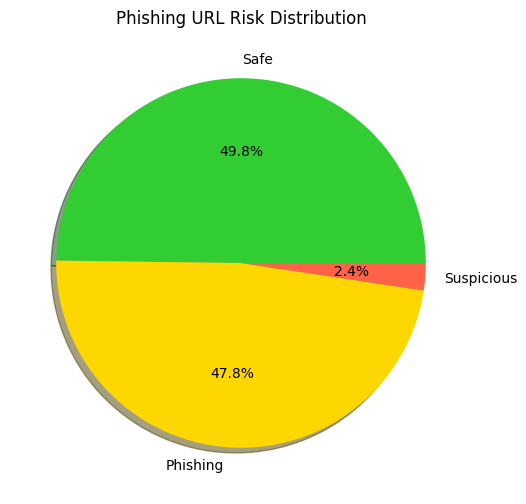

/tmp/ipython-input-2341767554.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk_Level', data=df, palette=['limegreen','gold','tomato'])


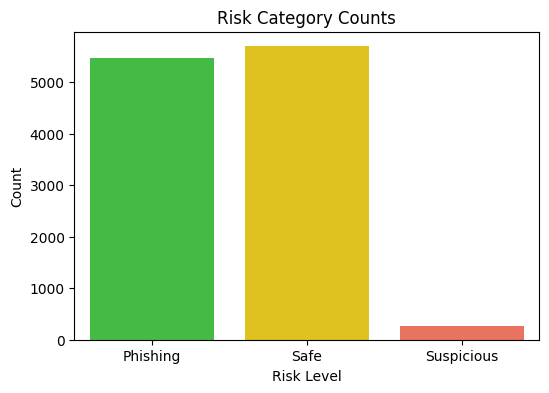

In [ ]:
#Risk Distribution Visuals

# Pie chart
plt.figure(figsize=(6,6))
df['Risk_Level'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                     colors=['limegreen','gold','tomato'],
                                     shadow=True)
plt.title("Phishing URL Risk Distribution")
plt.ylabel("")
plt.show()

# Bar chart
plt.figure(figsize=(6,4))
sns.countplot(x='Risk_Level', data=df, palette=['limegreen','gold','tomato'])
plt.title("Risk Category Counts")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()


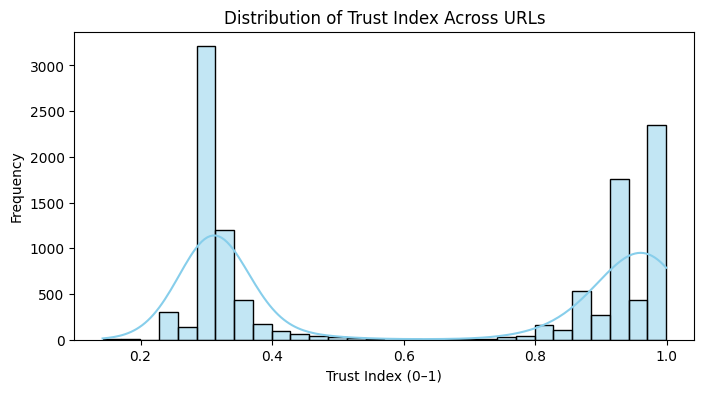

In [ ]:
#Trust index trend

plt.figure(figsize=(8,4))
sns.histplot(df['Trust_Index'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Trust Index Across URLs")
plt.xlabel("Trust Index (0–1)")
plt.ylabel("Frequency")
plt.show()



/tmp/ipython-input-473572989.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(rule_counts.keys()), y=list(rule_counts.values()), palette="viridis")


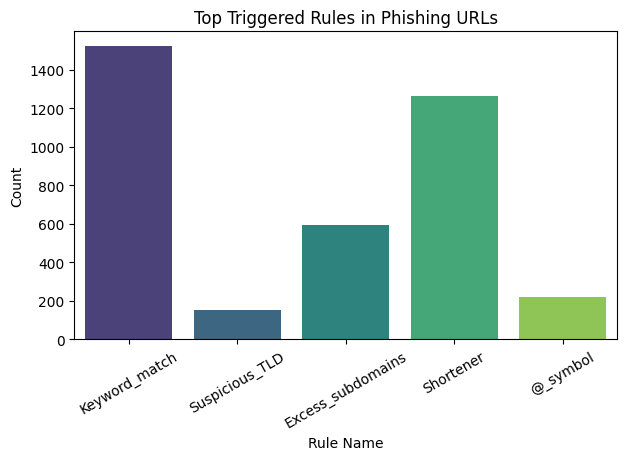

In [ ]:
#Most Triggered Rules (for novelty visualization)

from collections import Counter

all_rules = ",".join(df['triggered_rules'].dropna().tolist()).split(',')
rule_counts = Counter([r for r in all_rules if r])

plt.figure(figsize=(7,4))
sns.barplot(x=list(rule_counts.keys()), y=list(rule_counts.values()), palette="viridis")
plt.title("Top Triggered Rules in Phishing URLs")
plt.xlabel("Rule Name")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()


In [ ]:
#exporting
summary = df['Risk_Level'].value_counts(normalize=True).mul(100).round(2)
summary.to_csv(f"{base_path}/risk_summary.csv")
print("✅ Summary CSV saved as risk_summary.csv")
print(summary)


✅ Summary CSV saved as risk_summary.csv
Risk_Level
Safe          49.79
Phishing      47.83
Suspicious     2.38
Name: proportion, dtype: float64


# Day 4

## Part - 1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# base project directory
base_path = "/content/drive/MyDrive/Phishing_Project/data"
print("✅ Drive mounted and base path set:", base_path)


Mounted at /content/drive
✅ Drive mounted and base path set: /content/drive/MyDrive/Phishing_Project/data


In [ ]:
!pip install -q sentence-transformers==3.0.1 scikit-learn==1.5.2 joblib==1.4.2 streamlit==1.39.0


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.1/227.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 141.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 138.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 130.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 154.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 8.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
google-

In [ ]:
!pip install -q tldextract

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 4.1 MB/s eta 0:00:00


In [ ]:
import sklearn, joblib, streamlit, sentence_transformers
print("✅ scikit-learn:", sklearn.__version__)
print("✅ sentence-transformers:", sentence_transformers.__version__)
print("✅ Streamlit:", streamlit.__version__)


/usr/local/lib/python3.12/dist-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


✅ scikit-learn: 1.5.2
✅ sentence-transformers: 3.0.1
✅ Streamlit: 1.39.0


In [ ]:
import os, joblib, numpy as np

# list all files to confirm
os.listdir(base_path)


['phish_dataset.csv',
 'X_train.npy',
 'scaler.pkl',
 'y_test.npy',
 'y_train.npy',
 'X_test.npy',
 'rf_model.pkl',
 'tfidf_char_ngram_3_6.joblib',
 'scaler_numeric.joblib',
 'hybrid_data_joblib.pkl',
 'rf_hybrid_tfidf_numeric.pkl',
 'minilm_embeddings.npy',
 'bert_embeddings.npy',
 'scaler_hybrid.pkl',
 'rf_hybrid_minilm.pkl',
 'phish_with_rules.csv',
 'phish_with_trust_index.csv',
 'phish_final_triage.csv',
 'risk_summary.csv']

In [ ]:
#loadinng
rf_model = joblib.load(f"{base_path}/rf_hybrid_minilm.pkl")
scaler = joblib.load(f"{base_path}/scaler_hybrid.pkl")
print("✅ Model and scaler loaded successfully!")


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


✅ Model and scaler loaded successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
#Load MiniLM Model (Sentence-BERT)

from sentence_transformers import SentenceTransformer
minilm_model = SentenceTransformer("all-MiniLM-L6-v2")
print("✅ MiniLM model loaded successfully!")



model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ MiniLM model loaded successfully!


In [ ]:
# Test a Single MiniLM Embedding

sample = ["https://paypal-login.tk", "https://www.google.com"]
emb = minilm_model.encode(sample, show_progress_bar=False)
print("✅ Embedding shape:", emb.shape)


✅ Embedding shape: (2, 384)


In [ ]:
# Test Numeric Scaler

import pandas as pd
df_test = pd.read_csv(f"{base_path}/phish_dataset.csv").head(5)
feature_cols = [c for c in df_test.columns if c not in ['url','label']]
num_scaled = scaler.transform(df_test[feature_cols])
print("✅ Numeric scaler working; sample shape:", num_scaled.shape)


✅ Numeric scaler working; sample shape: (5, 87)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [ ]:
# Confirm Rule Engine Availability

import re, tldextract
SUSPICIOUS_TLDS = ["tk","ml","ga","cf","gq","xyz","top","club","work","zip","link","cn"]
PHISHING_KEYWORDS = ["login","verify","update","secure","account","bank","payment","signin","confirm"]
URL_SHORTENERS = ["bit.ly","tinyurl","goo.gl","t.co","is.gd","buff.ly","adf.ly","shorturl"]

def compute_rule_score(url):
    score, rules = 0, []
    ext = tldextract.extract(url)
    if ext.suffix in SUSPICIOUS_TLDS: score += 1; rules.append("Suspicious_TLD")
    if "@" in url: score += 1; rules.append("@_symbol")
    if url.count(".") > 4: score += 1; rules.append("Excess_subdomains")
    if any(k in url.lower() for k in PHISHING_KEYWORDS): score += 1; rules.append("Keyword_match")
    if any(short in url.lower() for short in URL_SHORTENERS): score += 1; rules.append("Shortener")
    return score/5, rules

print("✅ Rule engine ready.")


✅ Rule engine ready.


In [ ]:
# End-to-End Sanity Check

test_url = "https://paypal-login.tk"
# 1. get embedding
emb_vec = minilm_model.encode([test_url])
# 2. get numeric placeholder (dummy small vector)
import numpy as np
num_vec = np.zeros((1, len(scaler.mean_)))  # same shape as numeric features
num_scaled = scaler.transform(num_vec)
# 3. concat
X_test = np.hstack([emb_vec, num_scaled])
# 4. predict
prob = rf_model.predict_proba(X_test)[0][1]
rule_score, rules = compute_rule_score(test_url)
trust_index = 0.7*prob + 0.3*(1-rule_score)
print(f"ML_Prob={prob:.3f}, Rule={rule_score:.3f}, TrustIndex={trust_index:.3f}, Rules={rules}")


ML_Prob=0.694, Rule=0.400, TrustIndex=0.666, Rules=['Suspicious_TLD', 'Keyword_match']


## Part-2

In [ ]:
# helper imports + load metadata (feature list & means)


import pandas as pd, numpy as np, os, joblib

base_path = "/content/drive/MyDrive/Phishing_Project/data"

# load training dataset to get feature names & means
train_df = pd.read_csv(os.path.join(base_path, "phish_dataset.csv"))

# feature columns (numeric handcrafted features used in training)
feature_cols = [c for c in train_df.columns if c not in ['url','label','rule_score','triggered_rules','Trust_Index','Risk_Level','Triage_Explanation']]
print("Number of numeric feature columns expected by scaler:", len(feature_cols))

# compute mean values (used to fill features we don't compute right now)
feature_means = train_df[feature_cols].mean().to_dict()

# load scaler and model (ensure these files exist)
scaler = joblib.load(os.path.join(base_path, "scaler_hybrid.pkl"))
rf_model = joblib.load(os.path.join(base_path, "rf_hybrid_minilm.pkl"))

print("Loaded scaler and RF model. Example feature names:", feature_cols[:12])


Number of numeric feature columns expected by scaler: 87
Loaded scaler and RF model. Example feature names: ['length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore', 'nb_tilde']


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.5.2. This might lead to b

In [ ]:
# Cell B — basic numeric feature extractor for a single URL
import re
import tldextract
from urllib.parse import urlparse

# list of URL shorteners (same as rule engine)
URL_SHORTENERS = ["bit.ly","tinyurl","goo.gl","t.co","is.gd","buff.ly","adf.ly","shorturl","ow.ly","tiny.one"]

def extract_basic_numeric_features(url: str):
    # initialize dict
    out = {}
    u = str(url).strip()
    if not (u.startswith("http://") or u.startswith("https://")):
        # add http so urlparse works consistently
        u_parse = urlparse("http://" + u)
    else:
        u_parse = urlparse(u)
    host = u_parse.netloc
    path = u_parse.path or ""
    query = u_parse.query or ""
    full = u

    # core simple features (these map to many common feature names)
    out['length_url'] = len(full)
    out['length_hostname'] = len(host)
    out['ip'] = 1 if re.match(r'^\d{1,3}(\.\d{1,3}){3}$', host.split(':')[0]) else 0
    out['nb_dots'] = full.count('.')
    out['nb_hyphens'] = full.count('-')
    out['nb_at'] = full.count('@')
    out['nb_qm'] = full.count('?')
    out['nb_and'] = full.count('&')
    out['nb_or'] = full.count('|')
    out['nb_eq'] = full.count('=')
    out['nb_underscore'] = full.count('_')
    out['nb_tilde'] = full.count('~')
    out['nb_percent'] = full.count('%')
    out['nb_slash'] = full.count('/')
    out['nb_star'] = full.count('*')
    out['nb_colon'] = full.count(':')
    out['nb_comma'] = full.count(',')
    out['nb_semicolumn'] = full.count(';')
    out['nb_dollar'] = full.count('$')
    out['nb_space'] = full.count(' ')
    out['nb_www'] = 1 if 'www.' in full.lower() else 0
    out['nb_com'] = 1 if '.com' in full.lower() else 0
    out['nb_dslash'] = full.count('//')
    out['http_in_path'] = 1 if 'http' in path.lower() else 0
    out['https_token'] = 1 if 'https' in full.lower() else 0
    # ratio digits
    digits_in_url = sum(c.isdigit() for c in full)
    out['ratio_digits_url'] = digits_in_url / len(full) if len(full)>0 else 0.0
    digits_in_host = sum(c.isdigit() for c in host)
    out['ratio_digits_host'] = digits_in_host / len(host) if len(host)>0 else 0.0
    # punycode
    out['punycode'] = 1 if 'xn--' in host.lower() else 0
    # port
    out['port'] = 1 if ':' in host and host.split(':')[-1].isdigit() else 0
    # tld presence in path/subdomain
    ext = tldextract.extract(full)
    out['tld'] = ext.suffix or ''
    out['tld_in_path'] = 1 if out['tld'] and out['tld'] in path.lower() else 0
    out['tld_in_subdomain'] = 1 if out['tld'] and out['tld'] in ext.subdomain.lower() else 0
    out['nb_subdomains'] = len(ext.subdomain.split('.')) if ext.subdomain else 0
    out['shortening_service'] = 1 if any(s in full.lower() for s in URL_SHORTENERS) else 0
    # path extension
    out['path_extension'] = 1 if re.search(r'\.[a-zA-Z0-9]{1,5}$', path) else 0
    # basic words metrics
    words = re.findall(r'[A-Za-z0-9]+', full)
    out['length_words_raw'] = sum(len(w) for w in words)
    out['char_repeat'] = max((max([u.count(k) for k in set(full)]) if full else 0), 0)
    out['shortest_words_raw'] = min((len(w) for w in words), default=0)
    out['longest_words_raw'] = max((len(w) for w in words), default=0)
    out['avg_words_raw'] = (sum(len(w) for w in words) / len(words)) if words else 0
    # many other features exist in training data — not implemented here (will be filled from means)
    return out


In [ ]:
# Cell C — complete predict_url() function
import numpy as np
from typing import Dict

# load minilm model and rule function if not already loaded in session
# (assumes minilm_model, rf_model, scaler, feature_cols, feature_means, compute_rule_score are in scope)

def predict_url(url: str) -> Dict:
    url = str(url).strip()
    # 1) compute basic numeric features we implemented
    basic = extract_basic_numeric_features(url)

    # 2) create full feature vector in the exact order of feature_cols
    num_vec = []
    missing_features = []
    for f in feature_cols:
        if f in basic:
            val = basic[f]
        else:
            # if feature not computed, use mean from training
            val = feature_means.get(f, 0.0)
            missing_features.append(f)
        # ensure numeric type
        try:
            num_vec.append(float(val))
        except:
            num_vec.append(0.0)
    num_vec = np.array(num_vec).reshape(1, -1)  # shape (1, n_features)

    # 3) scale numeric features
    num_vec_scaled = scaler.transform(num_vec)

    # 4) compute embedding for the url (MiniLM)
    emb_vec = minilm_model.encode([url], show_progress_bar=False)
    # ensure emb_vec shape (1, 384)

    # 5) concat to hybrid feature vector
    X_hybrid = np.hstack([emb_vec, num_vec_scaled])

    # 6) ML probability from RF
    ml_prob = float(rf_model.predict_proba(X_hybrid)[0][1])

    # 7) rule score & triggered rules
    rule_score, triggered_rules = compute_rule_score(url)

    # 8) Trust Index (tunable weights)
    TRUST_WEIGHT_ML = 0.7
    TRUST_WEIGHT_RULE = 0.3
    trust_index = (TRUST_WEIGHT_ML * ml_prob) + (TRUST_WEIGHT_RULE * (1 - rule_score))
    # clamp to [0,1]
    trust_index = max(0.0, min(1.0, trust_index))

    # 9) risk level thresholds (customizable)
    if trust_index >= 0.70:
        risk = "Safe"
    elif trust_index >= 0.40:
        risk = "Suspicious"
    else:
        risk = "Phishing"

    # 10) explanation text
    explanation = (f"ML_prob={ml_prob:.3f}; rule_score={rule_score:.3f}; "
                   f"rules_triggered={'|'.join(triggered_rules) if triggered_rules else 'None'}; "
                   f"filled_features_count={len(missing_features)}")

    # 11) return a dict (easy to use in UI or logs)
    result = {
        "url": url,
        "ml_prob": ml_prob,
        "rule_score": rule_score,
        "triggered_rules": triggered_rules,
        "trust_index": trust_index,
        "risk_level": risk,
        "explanation": explanation,
        "numeric_features_filled_from_mean": missing_features
    }
    return result

# Quick example
print(predict_url("https://paypal-login.tk"))


{'url': 'https://paypal-login.tk', 'ml_prob': 0.5117686637993014, 'rule_score': 0.4, 'triggered_rules': ['Suspicious_TLD', 'Keyword_match'], 'trust_index': 0.538238064659511, 'risk_level': 'Suspicious', 'explanation': 'ML_prob=0.512; rule_score=0.400; rules_triggered=Suspicious_TLD|Keyword_match; filled_features_count=48', 'numeric_features_filled_from_mean': ['abnormal_subdomain', 'prefix_suffix', 'random_domain', 'nb_redirection', 'nb_external_redirection', 'shortest_word_host', 'shortest_word_path', 'longest_word_host', 'longest_word_path', 'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand', 'brand_in_subdomain', 'brand_in_path', 'suspecious_tld', 'statistical_report', 'nb_hyperlinks', 'ratio_intHyperlinks', 'ratio_extHyperlinks', 'ratio_nullHyperlinks', 'nb_extCSS', 'ratio_intRedirection', 'ratio_extRedirection', 'ratio_intErrors', 'ratio_extErrors', 'login_form', 'external_favicon', 'links_in_tags', 'submit_email', 'ratio_intMedia', 'ratio_extMedia', 'sfh', 'iframe

In [ ]:
import csv, datetime

log_path = os.path.join(base_path, "live_prediction_logs.csv")
def log_prediction(res_dict):
    header = ["timestamp","url","ml_prob","rule_score","trust_index","risk_level","triggered_rules","explanation"]
    write_header = not os.path.exists(log_path)
    with open(log_path, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(header)
        writer.writerow([
            datetime.datetime.utcnow().isoformat(),
            res_dict["url"],
            res_dict["ml_prob"],
            res_dict["rule_score"],
            res_dict["trust_index"],
            res_dict["risk_level"],
            ";".join(res_dict["triggered_rules"]),
            res_dict["explanation"]
        ])
    return log_path

# Example
r = predict_url("https://paypal-login.tk")
print("Logged at:", log_prediction(r))


Logged at: /content/drive/MyDrive/Phishing_Project/data/live_prediction_logs.csv


/tmp/ipython-input-2382817517.py:12: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  datetime.datetime.utcnow().isoformat(),


## Part-3

In [ ]:
!pip install pyngrok


In [ ]:
#Create a Streamlit App File

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import time
from datetime import datetime

# import the predict_url and log_prediction functions from your Colab session
# (since we're running inline, we'll redefine a lightweight wrapper)
from sentence_transformers import SentenceTransformer
import joblib, os, re, tldextract
from urllib.parse import urlparse

base_path = "/content/drive/MyDrive/Phishing_Project/data"

# --- Load Model and Scaler ---
rf_model = joblib.load(os.path.join(base_path, "rf_hybrid_minilm.pkl"))
scaler = joblib.load(os.path.join(base_path, "scaler_hybrid.pkl"))
minilm_model = SentenceTransformer("all-MiniLM-L6-v2")

# --- Rule Engine (reuse from earlier) ---
SUSPICIOUS_TLDS = ["tk","ml","ga","cf","gq","xyz","top","club","work","zip","link","cn"]
PHISHING_KEYWORDS = ["login","verify","update","secure","account","bank","payment","signin","confirm"]
URL_SHORTENERS = ["bit.ly","tinyurl","goo.gl","t.co","is.gd","buff.ly","adf.ly","shorturl"]

def compute_rule_score(url):
    score, rules = 0, []
    ext = tldextract.extract(url)
    if ext.suffix in SUSPICIOUS_TLDS: score += 1; rules.append("Suspicious_TLD")
    if "@" in url: score += 1; rules.append("@_symbol")
    if url.count(".") > 4: score += 1; rules.append("Excess_subdomains")
    if any(k in url.lower() for k in PHISHING_KEYWORDS): score += 1; rules.append("Keyword_match")
    if any(short in url.lower() for short in URL_SHORTENERS): score += 1; rules.append("Shortener")
    return score/5, rules

# --- Basic Numeric Feature Extractor (simplified for UI) ---
def extract_features(url):
    u = str(url)
    return {
        "length_url": len(u),
        "nb_dots": u.count("."),
        "nb_hyphens": u.count("-"),
        "https_token": 1 if "https" in u.lower() else 0,
        "ratio_digits_url": sum(c.isdigit() for c in u)/len(u) if len(u)>0 else 0,
    }

# --- Mini Predict Function (simplified for UI) ---
def predict_url_simple(url):
    emb = minilm_model.encode([url], show_progress_bar=False)
    # numeric placeholder
    feat = np.array(list(extract_features(url).values())).reshape(1,-1)
    # scale dummy numeric with same dimension
    pad = np.zeros((1, scaler.mean_.shape[0]-feat.shape[1]))
    num_scaled = np.hstack([feat, pad])
    # ML
    prob = rf_model.predict_proba(np.hstack([emb, num_scaled]))[0][1]
    rule_score, rules = compute_rule_score(url)
    trust_index = 0.7*prob + 0.3*(1-rule_score)
    trust_index = max(0.0, min(1.0, trust_index))
    if trust_index >= 0.70: risk="Safe"
    elif trust_index >= 0.40: risk="Suspicious"
    else: risk="Phishing"
    return prob, rule_score, trust_index, risk, rules

# --- Streamlit UI ---
st.set_page_config(page_title="PhishTriage – URL Detector", page_icon="🛡️", layout="centered")

st.title("🛡️ PhishTriage – Real-Time Phishing URL Detector")
st.markdown("Enter any URL below to analyze its risk level using our hybrid AI + Cybersecurity model.")

url_input = st.text_input("🔗 Enter URL here:", placeholder="https://example.com")
check_btn = st.button("Check URL")

if check_btn and url_input.strip():
    with st.spinner("Analyzing... Please wait"):
        prob, rule_score, trust_index, risk, rules = predict_url_simple(url_input)
        time.sleep(1.5)
    st.subheader("Results:")
    color = {"Safe":"green","Suspicious":"orange","Phishing":"red"}[risk]
    st.markdown(f"**Risk Level:** <span style='color:{color};font-size:22px'><b>{risk}</b></span>", unsafe_allow_html=True)
    st.progress(int(trust_index*100))
    st.write(f"**Trust Index:** {trust_index:.3f}")
    st.write(f"**Model Probability (Phishing):** {prob:.3f}")
    st.write(f"**Rule Score:** {rule_score:.3f}")
    st.write(f"**Triggered Rules:** {', '.join(rules) if rules else 'None'}")
    st.write(f"Checked at: {datetime.now().strftime('%Y-%m-d %H:%M:%S')}")
    st.success("✅ Analysis completed successfully!")
else:
    st.info("Enter a URL and click **Check URL** to begin.")


Overwriting app.py


In [ ]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0





  You can now view your Streamlit app in your browser.

  URL: http://0.0.0.0:8501

  Stopping...


In [ ]:
#part -4 : Live Integration & TestingLive Integration & Testing

In [ ]:
# Continued in VS Code Streamlit app

# Day-5

In [ ]:
pip install shap==0.46.0 matplotlib==3.9.2 seaborn==0.13.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 104.6 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
  Attempting uninstall: shap
    Found existing installation: shap 0.49.1
    Uninstalling shap-0.49.1:
      Successfully uninstalled shap-0.49.1


In [ ]:
# Continued VS code as explain_setup.py